In [3]:
# =============================================================================
# IPL CRICKET AUTOPSY -: EDA VISUALIZATION
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi']    = 130
plt.rcParams['font.family']   = 'sans-serif'

# =============================================================================
# LOAD DATA
# =============================================================================
df     = pd.read_csv("/kaggle/input/datasets/sangharshnikam/eda-file/ipl_cleaned.csv")
del_df = pd.read_csv("/kaggle/input/datasets/sangharshnikam/eda-file/ipl_deliveries_cleaned.csv")

# extras_type: 'wides','noballs','legbyes','byes','penalty'
# NO wide_runs / noball_runs columns in this dataset
legal_del  = del_df[~del_df["extras_type"].isin(["wides"])]
legal_bowl = del_df[~del_df["extras_type"].isin(["wides", "noballs"])]
wicket_del = del_df[
    (del_df["is_wicket"] == 1) &
    (~del_df["dismissal_kind"].isin(
        ["run out", "retired hurt", "obstructing the field"]))
]

print(f"Loaded  {len(df)} matches  |  {len(del_df):,} deliveries")
print("Charts will open one by one. Close each window to see the next.\n")


Loaded  1090 matches  |  260,920 deliveries
Charts will open one by one. Close each window to see the next.



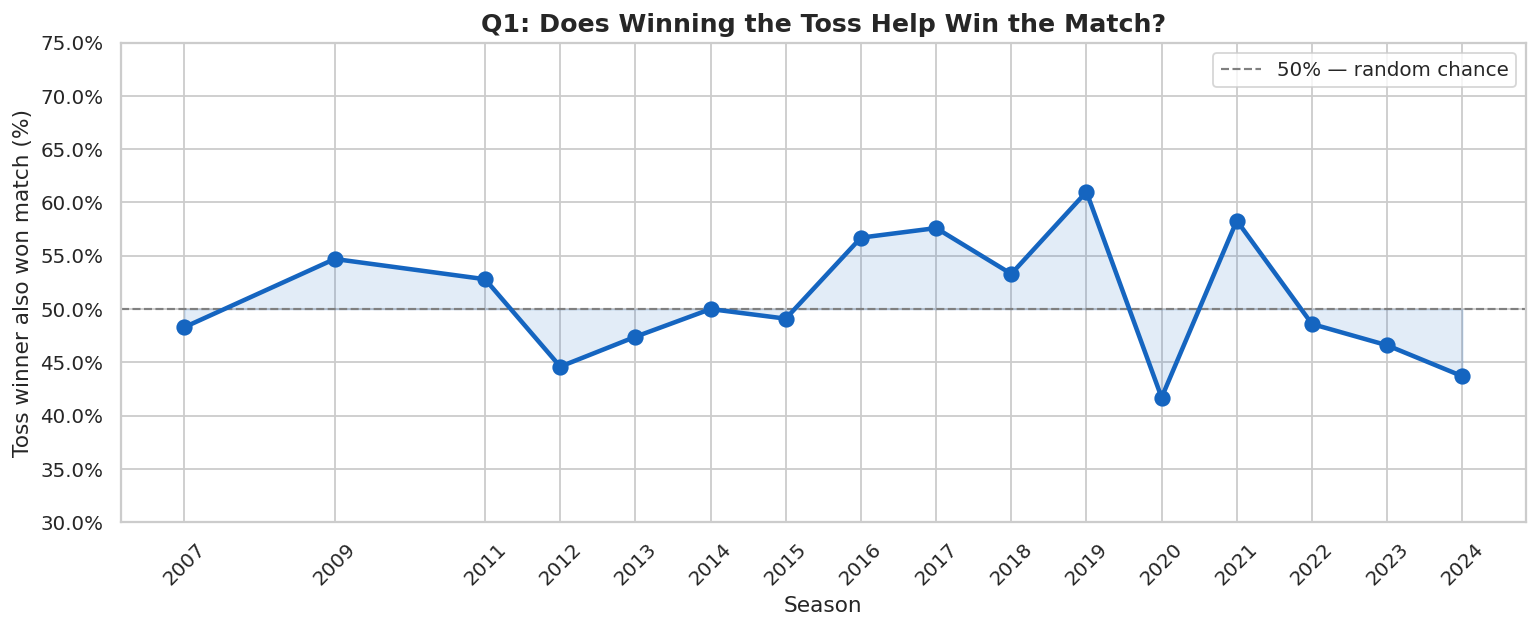

In [4]:
# =============================================================================
# CHART 1 — Q1: Does winning toss = winning match? (season-wise)
# =============================================================================
toss_s = (df.groupby("season")["toss_won_match"]
            .mean().mul(100).round(1)
            .reset_index(name="pct"))

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(50, color="gray", linestyle="--", linewidth=1.2,
           label="50% — random chance")
ax.plot(toss_s["season"], toss_s["pct"],
        marker="o", color="#1565C0", linewidth=2.5, markersize=8)
ax.fill_between(toss_s["season"], 50, toss_s["pct"],
                alpha=0.12, color="#1565C0")
ax.set_title("Q1: Does Winning the Toss Help Win the Match?",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Toss winner also won match (%)")
ax.set_ylim(30, 75)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(toss_s["season"])
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


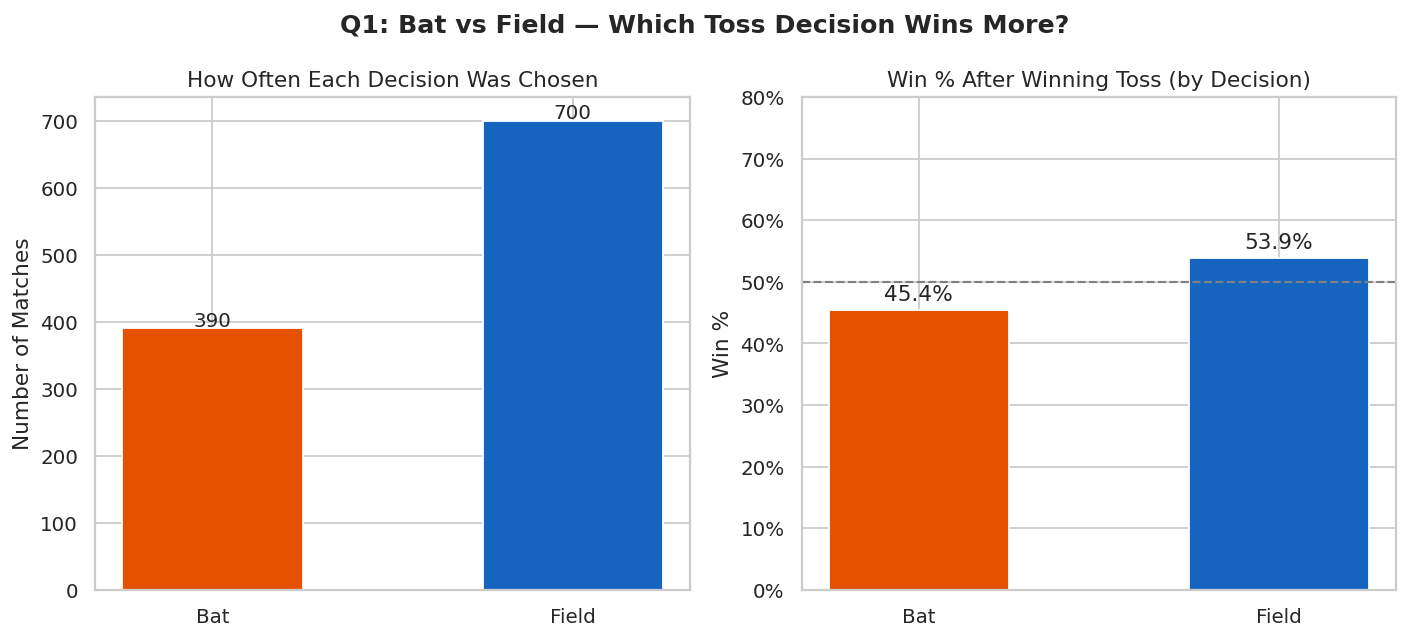

In [5]:
# =============================================================================
# CHART 2 — Q1: Bat vs Field — which decision wins more?
# =============================================================================
dec = (df[df["toss_decision"].isin(["bat", "field"])]
       .groupby("toss_decision")
       .agg(matches=("match_id", "count"),
            wins=("toss_won_match", "sum"))
       .reset_index())
dec["win_pct"] = (dec["wins"] / dec["matches"] * 100).round(1)
dec["label"]   = dec["toss_decision"].str.capitalize()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(dec["label"], dec["matches"],
            color=["#E65100", "#1565C0"], edgecolor="white", width=0.5)
for i, row in dec.iterrows():
    axes[0].text(i, row["matches"] + 3, str(row["matches"]),
                 ha="center", fontsize=11)
axes[0].set_title("How Often Each Decision Was Chosen", fontsize=12)
axes[0].set_ylabel("Number of Matches")

bars = axes[1].bar(dec["label"], dec["win_pct"],
                   color=["#E65100", "#1565C0"], edgecolor="white", width=0.5)
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1.2)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
axes[1].set_title("Win % After Winning Toss (by Decision)", fontsize=12)
axes[1].set_ylabel("Win %")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, 80)

fig.suptitle("Q1: Bat vs Field — Which Toss Decision Wins More?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


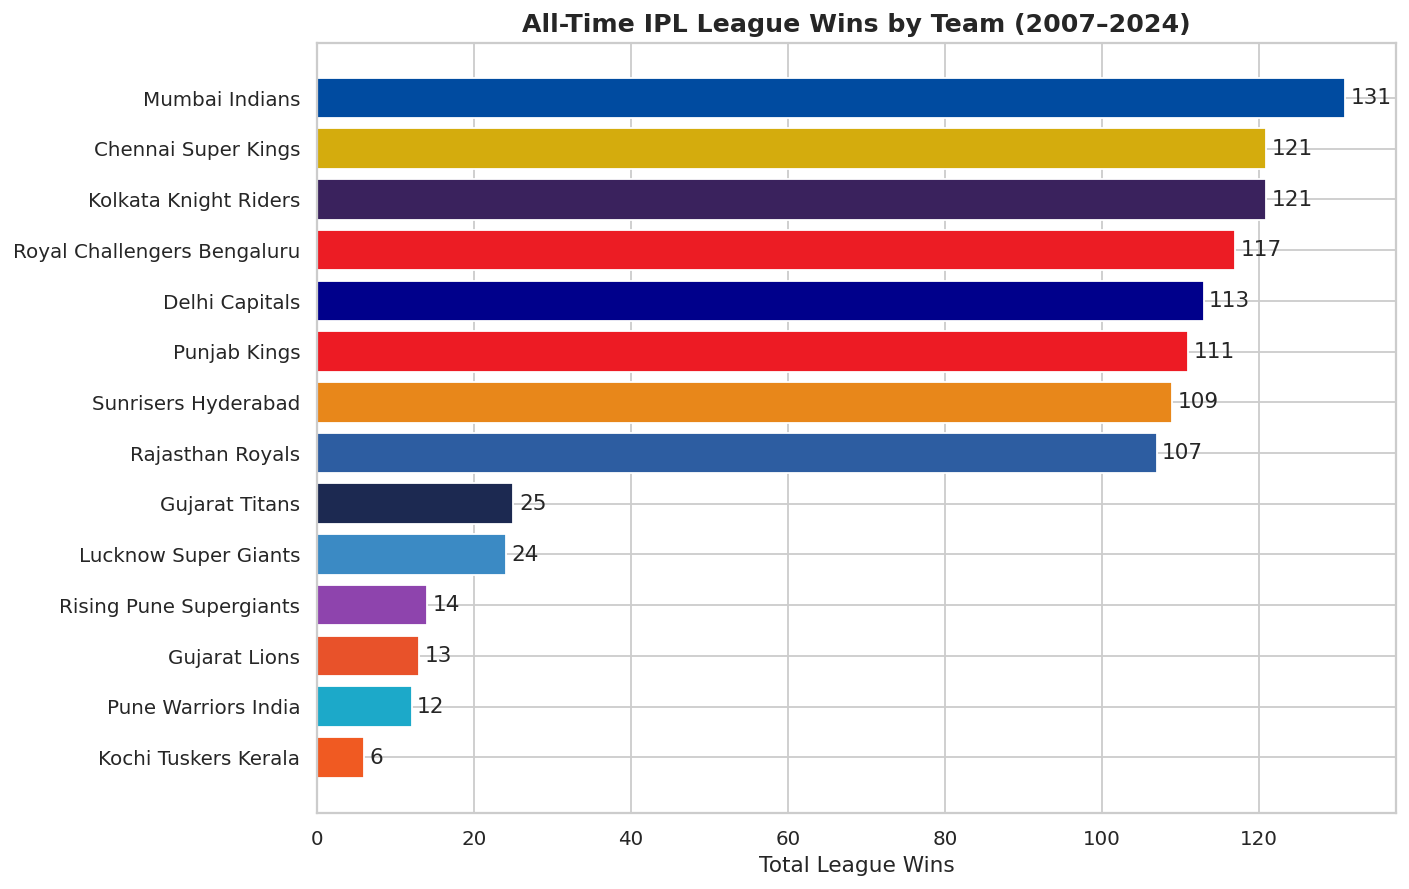

In [6]:
# =============================================================================
# CHART 3 — All-Time Wins by Team (League matches only)
# =============================================================================
TEAM_COLORS = {
    "Mumbai Indians"              : "#004BA0",
    "Chennai Super Kings"         : "#D4AC0D",
    "Kolkata Knight Riders"       : "#3A225D",
    "Royal Challengers Bengaluru" : "#EC1C24",
    "Delhi Capitals"              : "#00008B",
    "Punjab Kings"                : "#ED1B24",
    "Sunrisers Hyderabad"         : "#E8871A",
    "Rajasthan Royals"            : "#2D5DA1",
    "Gujarat Titans"              : "#1C2951",
    "Lucknow Super Giants"        : "#3B8AC4",
    "Rising Pune Supergiants"     : "#8E44AD",
    "Pune Warriors India"         : "#1CA9C9",
    "Deccan Chargers"             : "#FF7F00",
    "Kochi Tuskers Kerala"        : "#F05A22",
    "Gujarat Lions"               : "#E8522A",
}

league_wins = (df[df["match_type"] == "League"]["winner"]
               .value_counts().reset_index())
league_wins.columns = ["team", "wins"]
league_wins = league_wins.sort_values("wins", ascending=True)
colors = [TEAM_COLORS.get(t, "#888888") for t in league_wins["team"]]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(league_wins["team"], league_wins["wins"],
               color=colors, edgecolor="white")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Total League Wins")
ax.set_title("All-Time IPL League Wins by Team (2007–2024)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


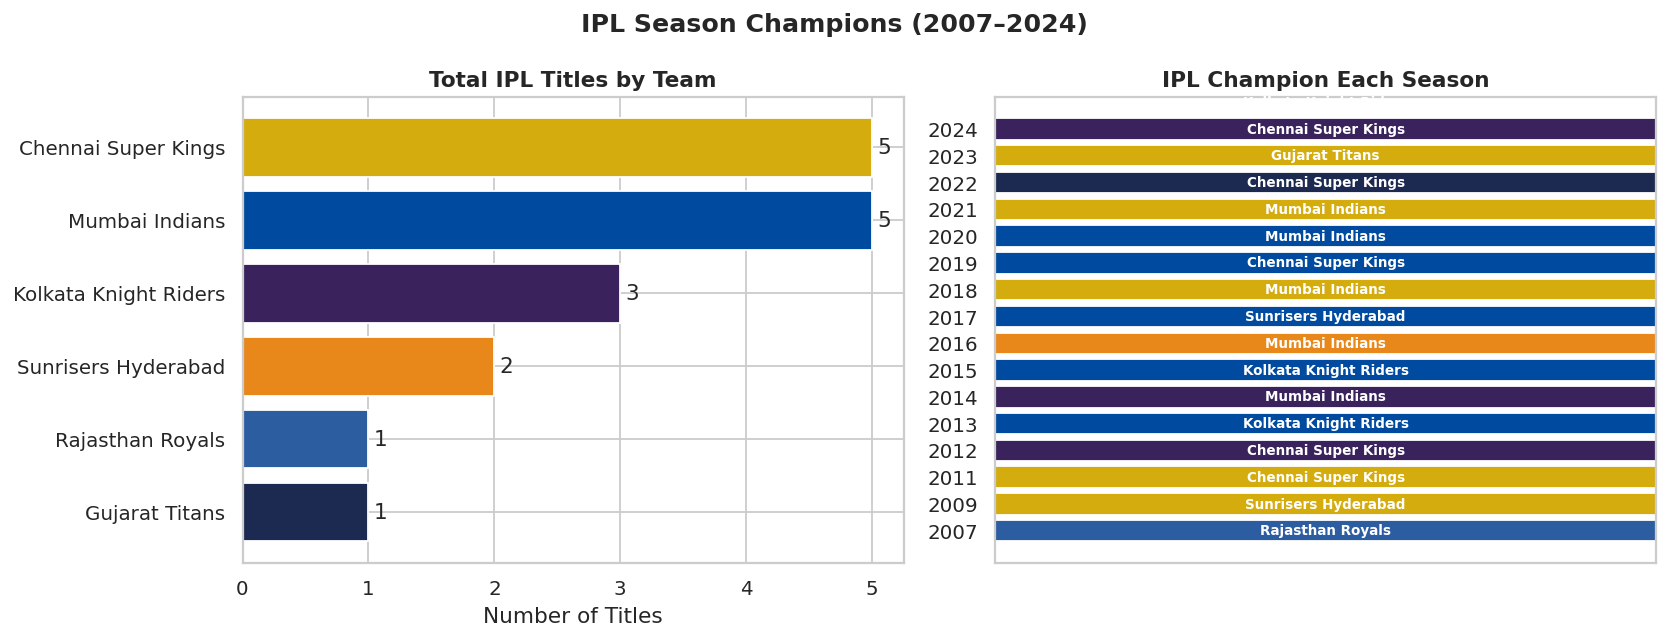

In [7]:
# =============================================================================
# CHART 4 — Season Champions
# =============================================================================
champs = (df[df["match_type"] == "Final"]
          [["season", "winner"]]
          .sort_values("season"))
title_counts = champs["winner"].value_counts().reset_index()
title_counts.columns = ["team", "titles"]
title_counts = title_counts.sort_values("titles", ascending=True)
tc_colors = [TEAM_COLORS.get(t, "#888888") for t in title_counts["team"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — titles by team
bars = axes[0].barh(title_counts["team"], title_counts["titles"],
                    color=tc_colors, edgecolor="white")
axes[0].bar_label(bars, padding=3)
axes[0].set_xlabel("Number of Titles")
axes[0].set_title("Total IPL Titles by Team", fontsize=12, fontweight="bold")

# Right — champion per season
champ_colors = [TEAM_COLORS.get(t, "#888888") for t in champs["winner"]]
axes[1].barh(champs["season"].astype(str), [1]*len(champs),
             color=champ_colors, edgecolor="white")
for i, (_, row) in enumerate(champs.iterrows()):
    axes[1].text(0.5, i, row["winner"], va="center", ha="center",
                 fontsize=7.5, color="white", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_title("IPL Champion Each Season", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 1)
axes[1].get_xaxis().set_visible(False)

fig.suptitle("IPL Season Champions (2007–2024)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


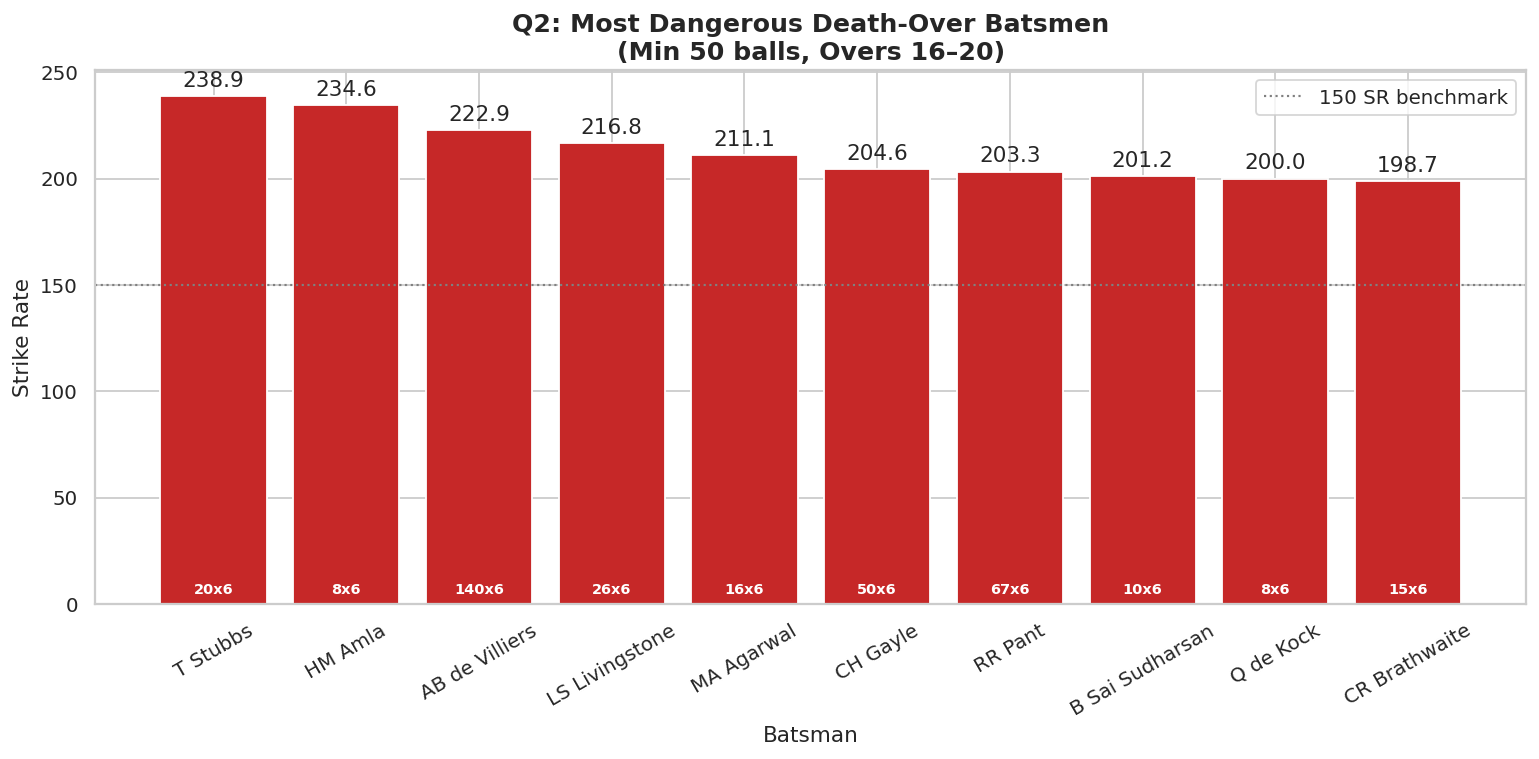

In [8]:
# =============================================================================
# CHART 5 — Q2: Most Dangerous Death-Over Batsmen (overs 16-20)
# =============================================================================
death = legal_del[legal_del["over"].between(15, 19)]
db = death.groupby("batsman").agg(
    runs  = ("batsman_runs", "sum"),
    balls = ("ball", "count"),
    sixes = ("batsman_runs", lambda x: (x == 6).sum()),
).reset_index()
db["sr"]   = (db["runs"] / db["balls"] * 100).round(1)
top_death  = db[db["balls"] >= 50].nlargest(10, "sr")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_death["batsman"], top_death["sr"],
              color="#C62828", edgecolor="white")
ax.bar_label(bars, padding=3, fmt="%.1f")
ax.axhline(150, color="gray", linestyle=":", linewidth=1.2,
           label="150 SR benchmark")
for i, row in top_death.reset_index().iterrows():
    ax.text(i, 5, f"{row['sixes']}x6", ha="center",
            fontsize=8, color="white", fontweight="bold")
ax.set_title("Q2: Most Dangerous Death-Over Batsmen\n(Min 50 balls, Overs 16–20)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Batsman")
ax.set_ylabel("Strike Rate")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


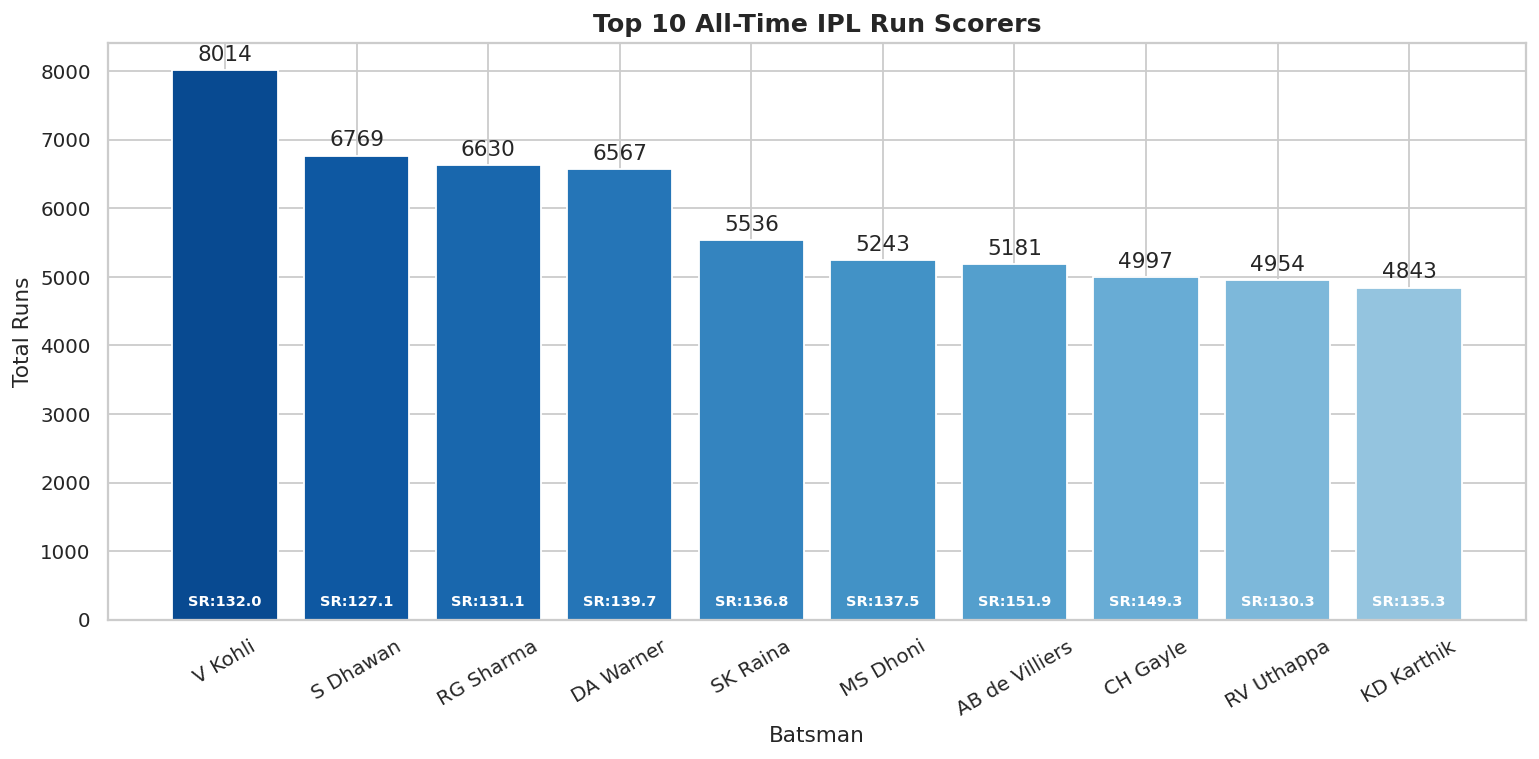

In [9]:
# =============================================================================
# CHART 6 — Top 10 All-Time Run Scorers
# =============================================================================
bat = legal_del.groupby("batsman").agg(
    runs  = ("batsman_runs", "sum"),
    balls = ("ball", "count"),
    sixes = ("batsman_runs", lambda x: (x == 6).sum()),
    fours = ("batsman_runs", lambda x: (x == 4).sum()),
).reset_index()
bat["sr"]  = (bat["runs"] / bat["balls"] * 100).round(1)
top10_bat  = bat.nlargest(10, "runs")

colors_b = plt.cm.Blues(np.linspace(0.4, 0.9, 10))[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top10_bat["batsman"], top10_bat["runs"],
              color=colors_b, edgecolor="white")
ax.bar_label(bars, padding=3)
for i, row in top10_bat.reset_index().iterrows():
    ax.text(i, 200, f"SR:{row['sr']}", ha="center",
            fontsize=8, color="white", fontweight="bold")
ax.set_title("Top 10 All-Time IPL Run Scorers",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Batsman")
ax.set_ylabel("Total Runs")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

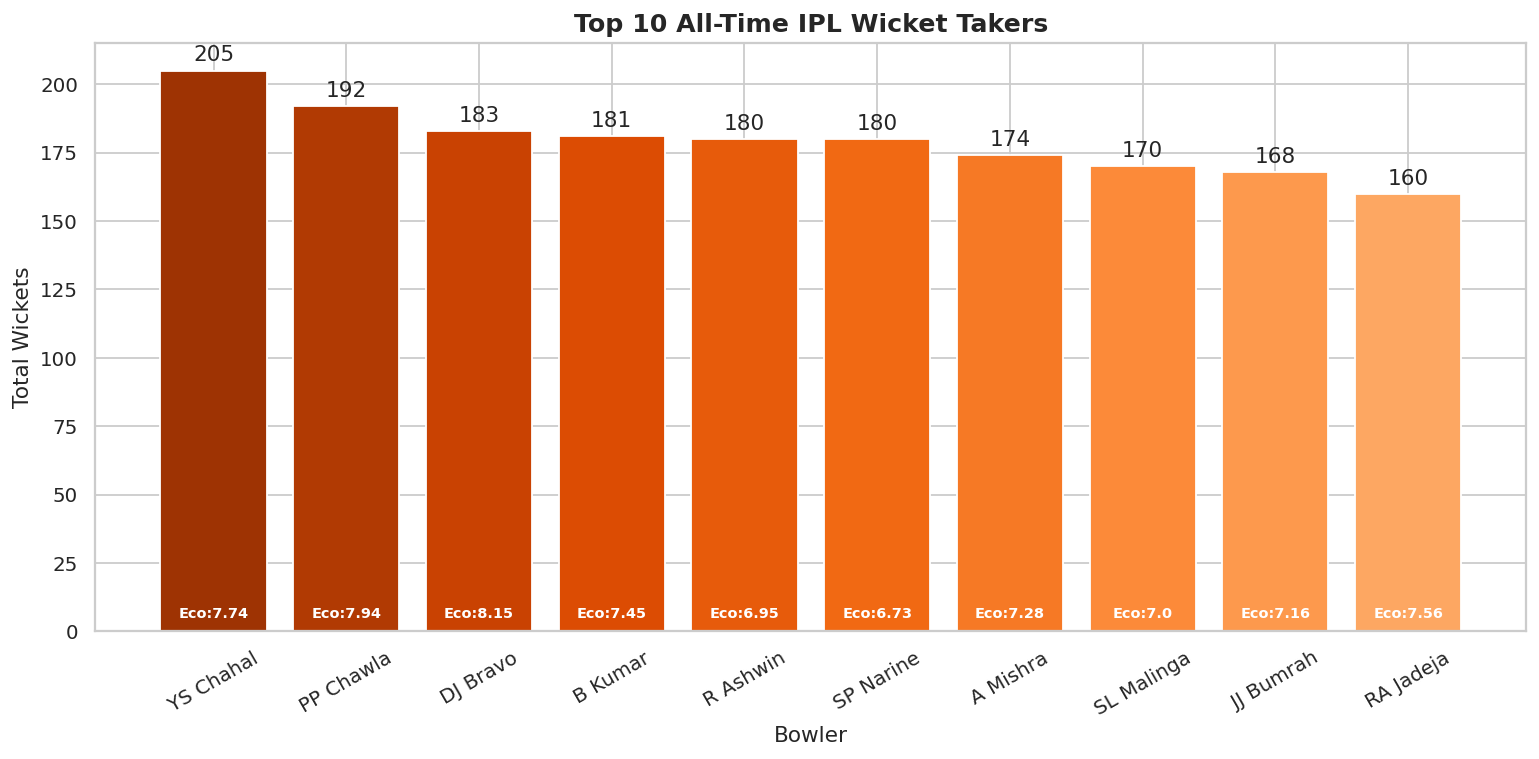

In [10]:
# =============================================================================
# CHART 7 — Top 10 All-Time Wicket Takers
# =============================================================================
bowlers    = wicket_del.groupby("bowler").size().reset_index(name="wickets")
econ       = legal_bowl.groupby("bowler").agg(
    balls = ("ball", "count"),
    runs  = ("total_runs", "sum"),
).reset_index()
econ["economy"] = (econ["runs"] / econ["balls"] * 6).round(2)
bowlers    = bowlers.merge(econ, on="bowler")
top10_bowl = bowlers[bowlers["balls"] >= 200].nlargest(10, "wickets")

colors_o = plt.cm.Oranges(np.linspace(0.4, 0.9, 10))[::-1]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top10_bowl["bowler"], top10_bowl["wickets"],
              color=colors_o, edgecolor="white")
ax.bar_label(bars, padding=3)
for i, row in top10_bowl.reset_index().iterrows():
    ax.text(i, 5, f"Eco:{row['economy']}", ha="center",
            fontsize=8, color="white", fontweight="bold")
ax.set_title("Top 10 All-Time IPL Wicket Takers",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Bowler")
ax.set_ylabel("Total Wickets")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


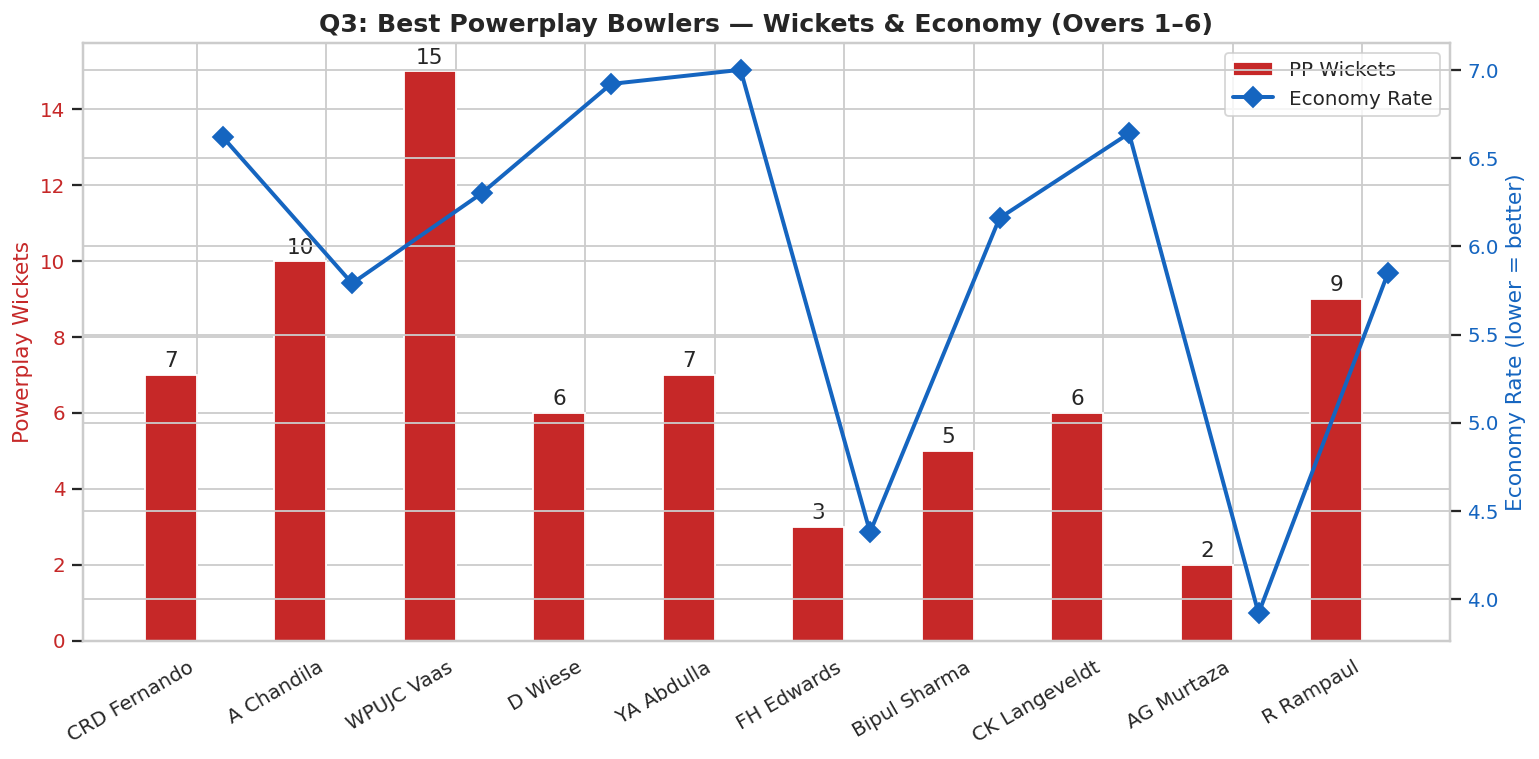

In [11]:
# =============================================================================
# CHART 8 — Q3: Best Powerplay Bowlers (overs 1-6)
# =============================================================================
pp       = del_df[del_df["over"].between(0, 5)]
pp_wkts  = (pp[(pp["is_wicket"] == 1) &
               (~pp["dismissal_kind"].isin(["run out", "retired hurt"]))]
            .groupby("bowler").size().reset_index(name="pp_wkts"))
pp_legal = (pp[~pp["extras_type"].isin(["wides", "noballs"])]
            .groupby("bowler")
            .agg(balls=("ball", "count"), runs=("total_runs", "sum"))
            .reset_index())
pp_legal["economy"] = (pp_legal["runs"] / pp_legal["balls"] * 6).round(2)
pp_df    = pp_wkts.merge(pp_legal, on="bowler")
pp_df    = pp_df[pp_df["balls"] >= 60]
pp_df["rating"] = (
    (pp_df["pp_wkts"] / (pp_df["balls"] / 6)) * 10
    + (8 - pp_df["economy"])
).round(2)
top_pp   = pp_df.nlargest(10, "rating").reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(top_pp))
w = 0.4

bars1 = ax1.bar([i - w/2 for i in x], top_pp["pp_wkts"],
                width=w, color="#C62828", edgecolor="white",
                label="PP Wickets")
ax1.set_ylabel("Powerplay Wickets", color="#C62828")
ax1.tick_params(axis="y", labelcolor="#C62828")
ax1.bar_label(bars1, padding=2)

ax2 = ax1.twinx()
ax2.plot([i + w/2 for i in x], top_pp["economy"],
         marker="D", color="#1565C0", linewidth=2.2,
         markersize=8, label="Economy Rate")
ax2.set_ylabel("Economy Rate (lower = better)", color="#1565C0")
ax2.tick_params(axis="y", labelcolor="#1565C0")

ax1.set_xticks(list(x))
ax1.set_xticklabels(top_pp["bowler"], rotation=30, ha="right")
ax1.set_title("Q3: Best Powerplay Bowlers — Wickets & Economy (Overs 1–6)",
              fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()



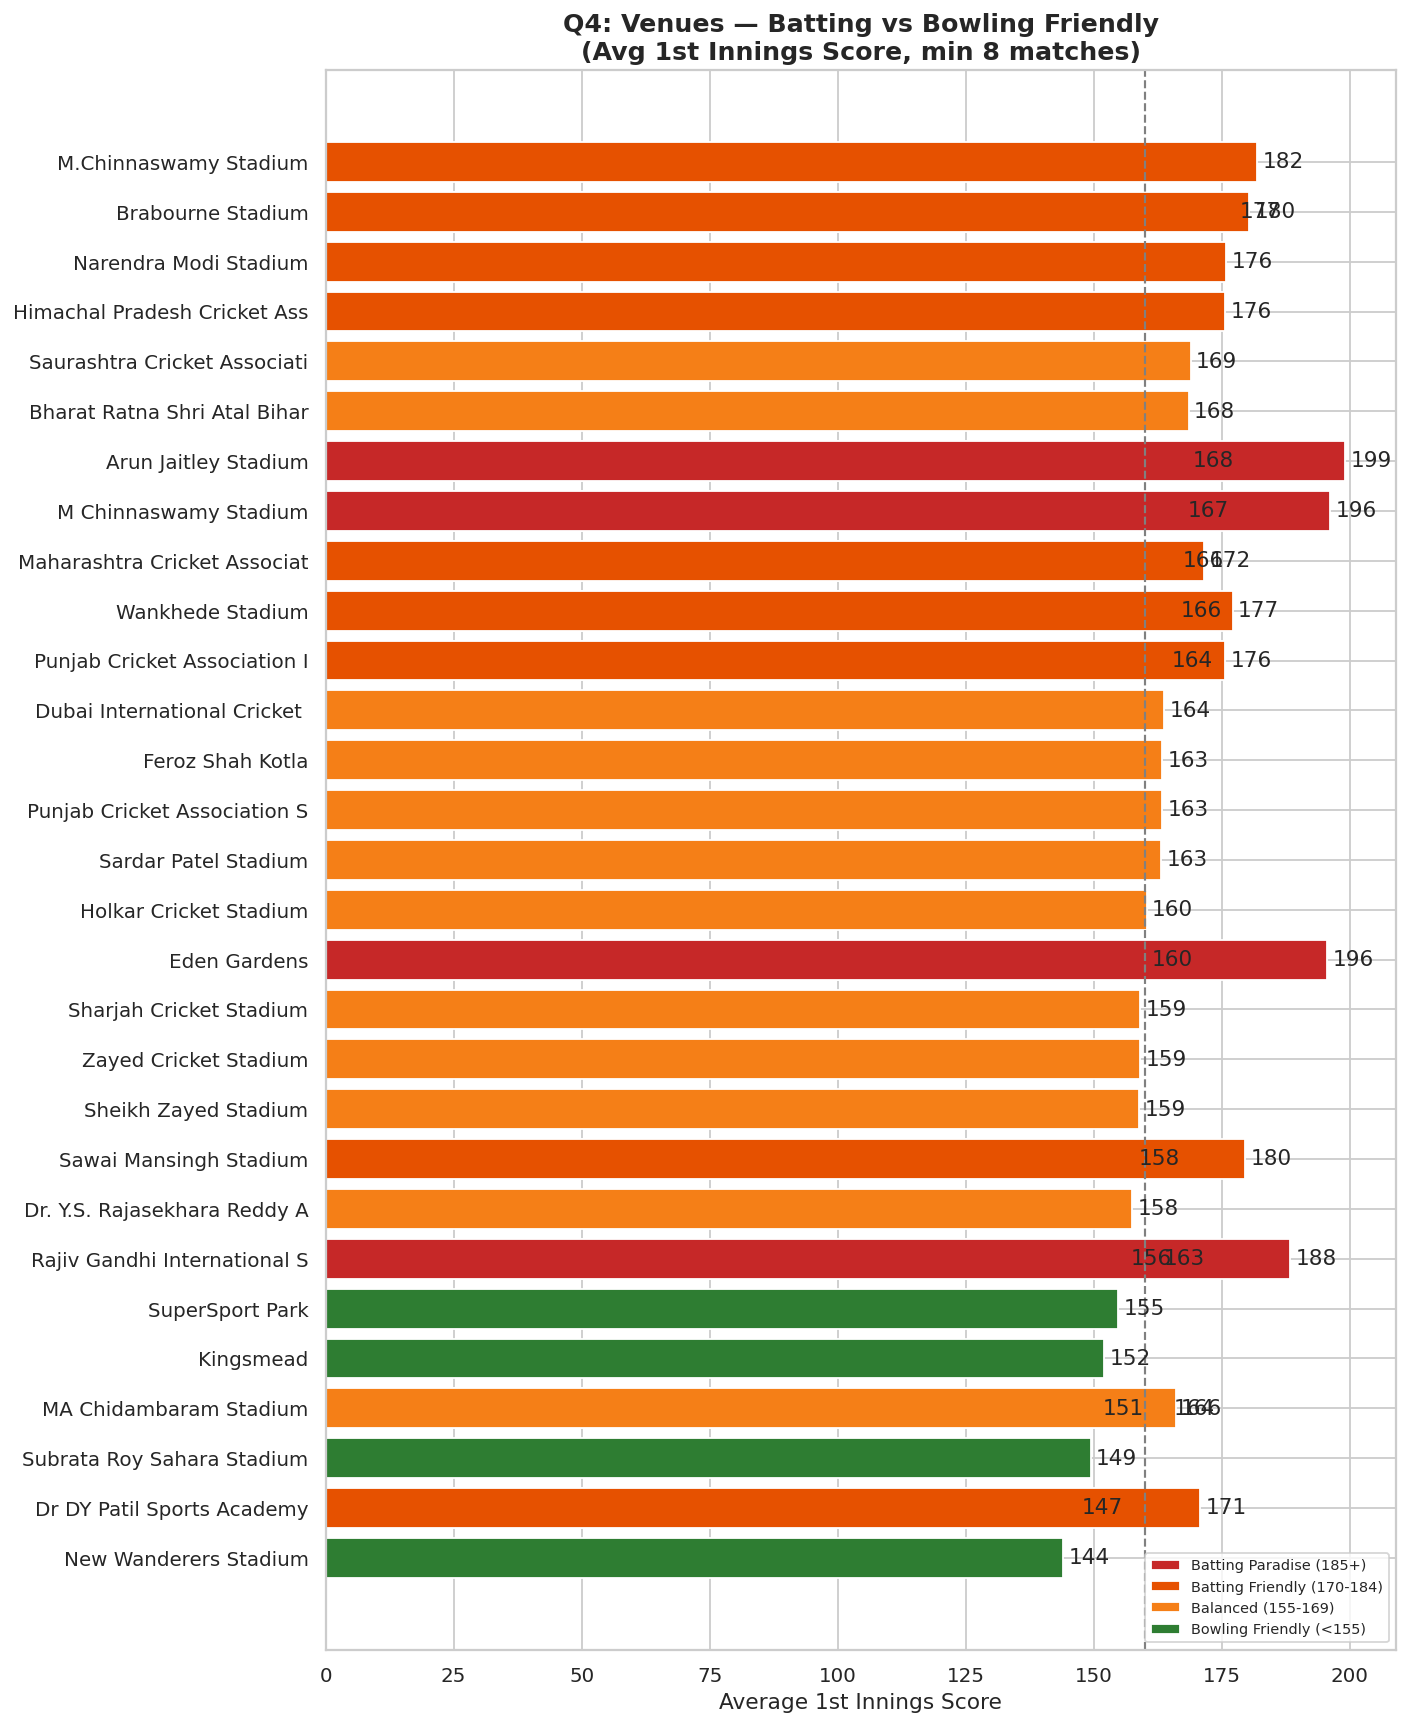

In [12]:
# =============================================================================
# CHART 9 — Q4: Venues — Batting vs Bowling Friendly
# =============================================================================
venue = df.groupby("venue").agg(
    matches  = ("match_id", "count"),
    avg_inn1 = ("inn1_runs", "mean"),
).reset_index()
venue = venue[venue["matches"] >= 8].copy()
venue["avg_inn1"] = venue["avg_inn1"].round(1)
venue["short"]    = venue["venue"].apply(lambda v: v.split(",")[0][:28])

def venue_color(avg):
    if avg >= 185:   return "#C62828"
    elif avg >= 170: return "#E65100"
    elif avg >= 155: return "#F57F17"
    else:            return "#2E7D32"

venue["color"] = venue["avg_inn1"].apply(venue_color)
venue = venue.sort_values("avg_inn1", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(6, len(venue) * 0.32)))
bars = ax.barh(venue["short"], venue["avg_inn1"],
               color=venue["color"].tolist(), edgecolor="white")
ax.axvline(160, color="gray", linestyle="--", linewidth=1.2,
           label="160 run benchmark")
ax.bar_label(bars, padding=3, fmt="%.0f")
ax.set_xlabel("Average 1st Innings Score")
ax.set_title("Q4: Venues — Batting vs Bowling Friendly\n"
             "(Avg 1st Innings Score, min 8 matches)",
             fontsize=14, fontweight="bold")

legend_els = [
    Patch(facecolor="#C62828", label="Batting Paradise (185+)"),
    Patch(facecolor="#E65100", label="Batting Friendly (170-184)"),
    Patch(facecolor="#F57F17", label="Balanced (155-169)"),
    Patch(facecolor="#2E7D32", label="Bowling Friendly (<155)"),
]
ax.legend(handles=legend_els, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


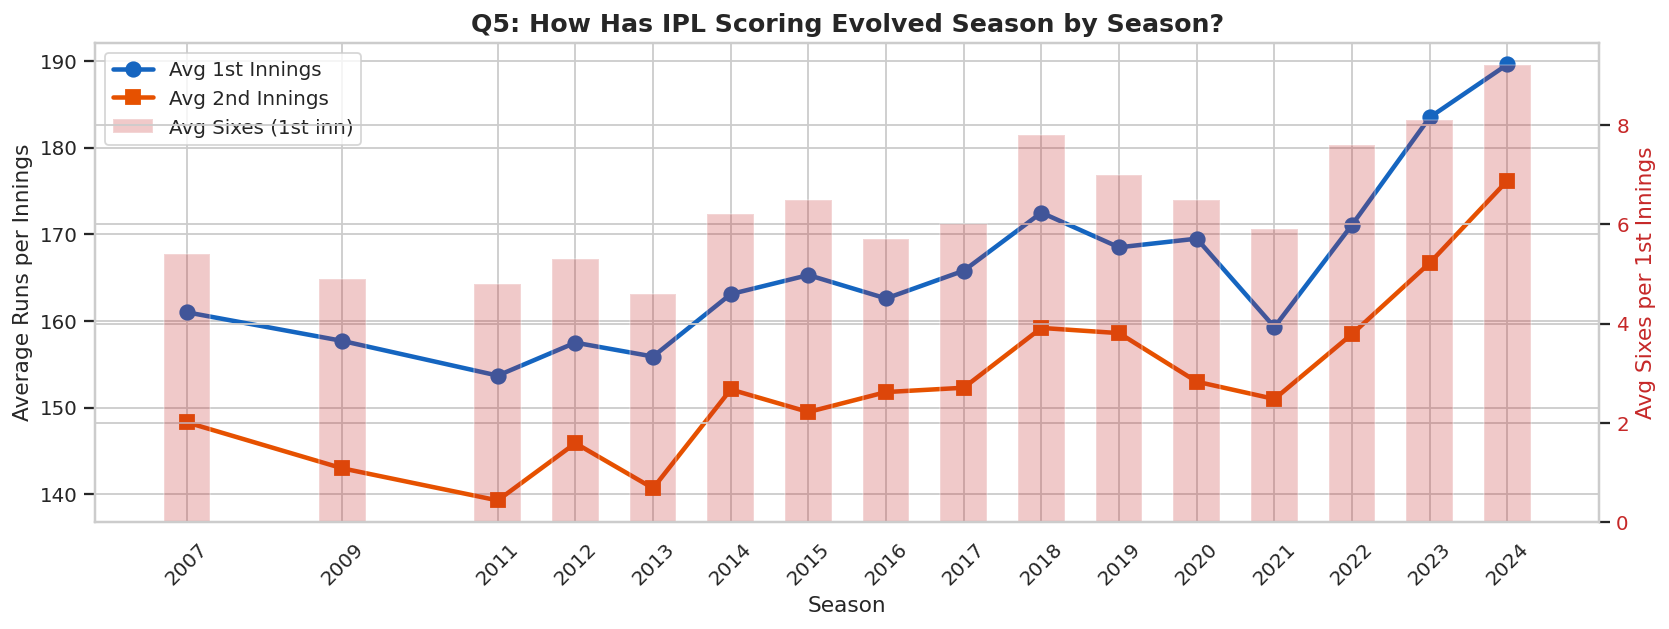

In [13]:
# =============================================================================
# CHART 10 — Q5: Scoring Evolution Season by Season
# =============================================================================
scoring = df.groupby("season").agg(
    avg_inn1  = ("inn1_runs", "mean"),
    avg_inn2  = ("inn2_runs", "mean"),
    avg_sixes = ("inn1_sixes", "mean"),
).reset_index().round(1)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(scoring["season"], scoring["avg_inn1"],
         marker="o", color="#1565C0", linewidth=2.5,
         markersize=8, label="Avg 1st Innings")
ax1.plot(scoring["season"], scoring["avg_inn2"],
         marker="s", color="#E65100", linewidth=2.5,
         markersize=8, label="Avg 2nd Innings")
ax1.set_ylabel("Average Runs per Innings")
ax1.set_xlabel("Season")
ax1.set_xticks(scoring["season"])
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(scoring["season"], scoring["avg_sixes"],
        alpha=0.25, color="#C62828", width=0.6, label="Avg Sixes (1st inn)")
ax2.set_ylabel("Avg Sixes per 1st Innings", color="#C62828")
ax2.tick_params(axis="y", labelcolor="#C62828")

ax1.set_title("Q5: How Has IPL Scoring Evolved Season by Season?",
              fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()


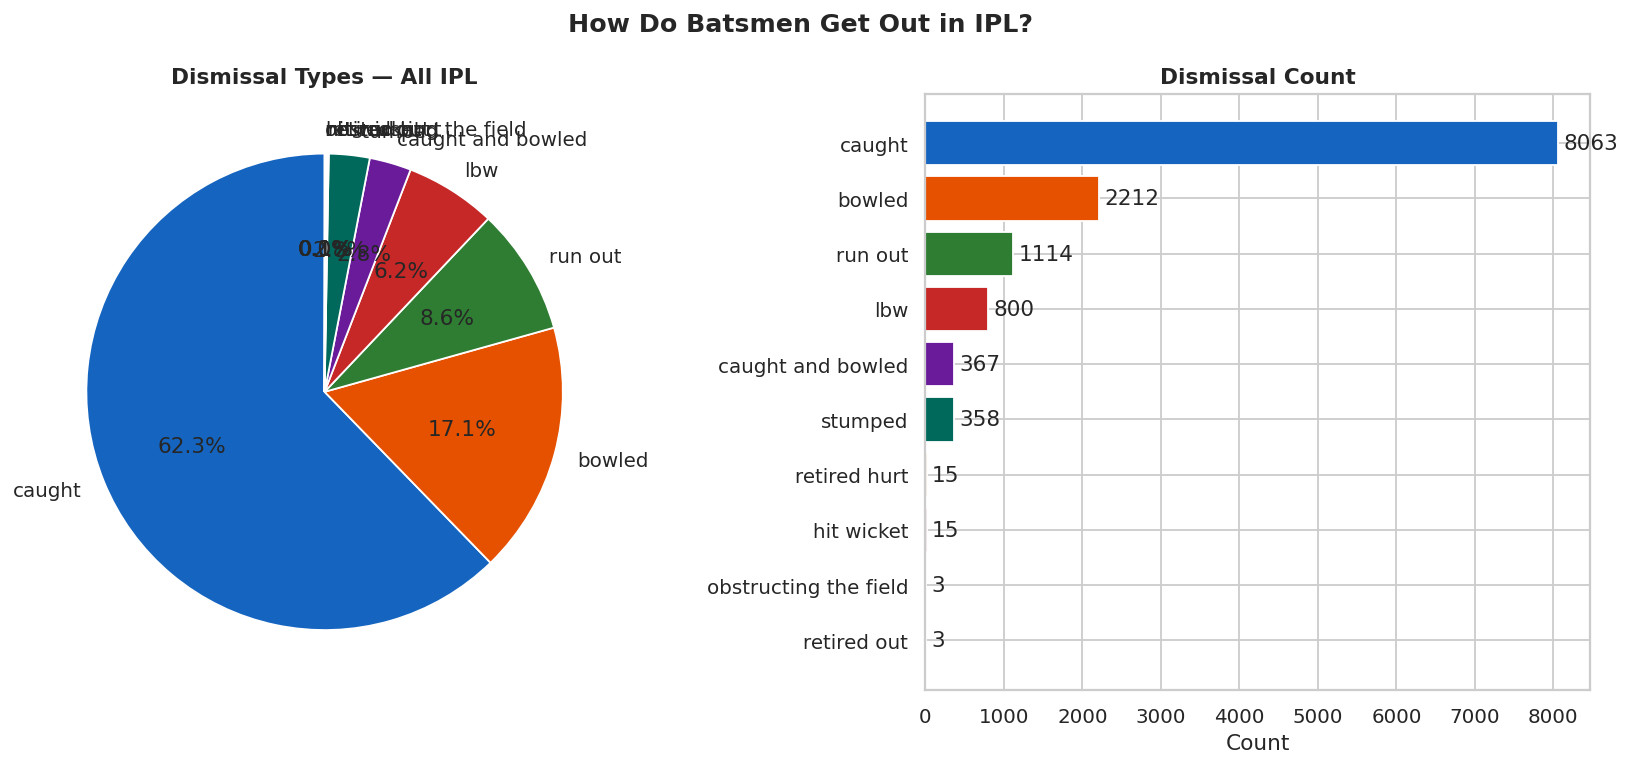

In [14]:
# =============================================================================
# CHART 11 — Dismissal Types
# =============================================================================
dis = (del_df[del_df["is_wicket"] == 1]["dismissal_kind"]
       .dropna().value_counts().reset_index())
dis.columns = ["type", "count"]

colors_d = ["#1565C0","#E65100","#2E7D32","#C62828","#6A1B9A",
            "#00695C","#F57F17","#AD1457","#00838F","#558B2F"]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Pie
wedges, texts, autotexts = axes[0].pie(
    dis["count"], labels=dis["type"],
    autopct="%1.1f%%", startangle=90,
    colors=colors_d[:len(dis)]
)
axes[0].set_title("Dismissal Types — All IPL", fontsize=12, fontweight="bold")

# Bar
bars = axes[1].barh(dis["type"][::-1], dis["count"][::-1],
                    color=colors_d[:len(dis)][::-1], edgecolor="white")
axes[1].bar_label(bars, padding=3)
axes[1].set_xlabel("Count")
axes[1].set_title("Dismissal Count", fontsize=12, fontweight="bold")

fig.suptitle("How Do Batsmen Get Out in IPL?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



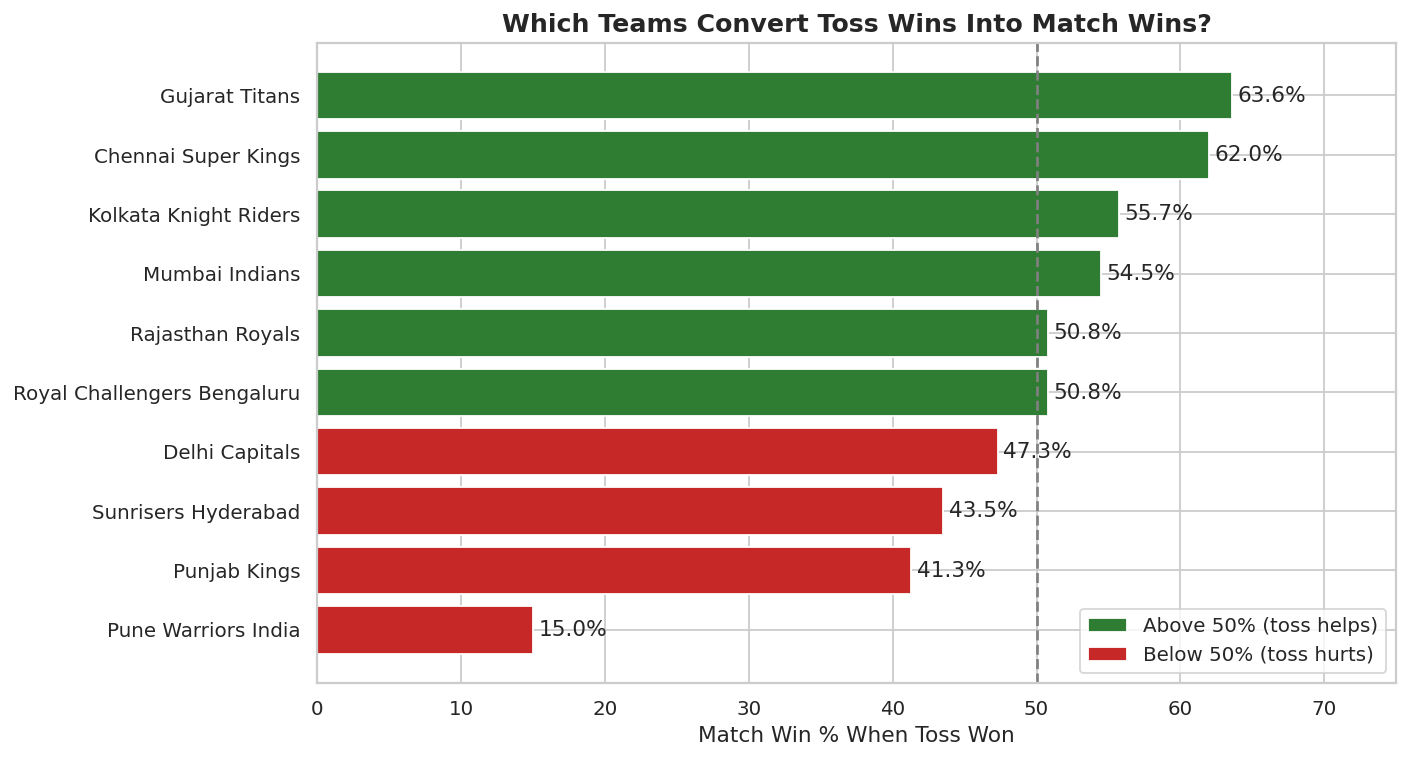

In [15]:

# =============================================================================
# CHART 12 — Toss Conversion % Per Team
# =============================================================================
toss_team = (df.groupby("toss_winner")
               .agg(toss_wins =("match_id", "count"),
                    match_wins=("toss_won_match", "sum"))
               .reset_index())
toss_team["win_pct"] = (
    toss_team["match_wins"] / toss_team["toss_wins"] * 100
).round(1)
toss_team = (toss_team[toss_team["toss_wins"] >= 20]
             .sort_values("win_pct", ascending=True))

bar_colors = ["#C62828" if p < 50 else "#2E7D32"
              for p in toss_team["win_pct"]]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(toss_team["toss_winner"], toss_team["win_pct"],
               color=bar_colors, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1.5,
           label="50% baseline")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlabel("Match Win % When Toss Won")
ax.set_xlim(0, 75)
ax.set_title("Which Teams Convert Toss Wins Into Match Wins?",
             fontsize=14, fontweight="bold")

legend_els = [
    Patch(facecolor="#2E7D32", label="Above 50% (toss helps)"),
    Patch(facecolor="#C62828", label="Below 50% (toss hurts)"),
]
ax.legend(handles=legend_els, loc="lower right")
plt.tight_layout()
plt.show()
